# 1. Préparation et Exploration des Données

In [20]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# ---------------------------
# A. Chargement des données
# ---------------------------

# Lecture du fichier CSV en précisant que la colonne 'Datetime' doit être convertie en datetime
df = pd.read_csv('cac40_clean_format.csv', parse_dates=['Datetime'])

# Affichage des premières lignes pour vérifier que les données sont correctement chargées
print("Premières lignes du DataFrame :")
print(df.head())

# Affichage des informations sur le DataFrame pour vérifier les types de données
print("\nInformations sur le DataFrame :")
print(df.info())

Premières lignes du DataFrame :
                   Datetime  Price  Ticker       Value
0 2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1 2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2 2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3 2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4 2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000

Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  913740 non-null  datetime64[ns, UTC]
 1   Price     913740 non-null  object             
 2   Ticker    913740 non-null  object             
 3   Value     913740 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 27.9+ MB
None


In [22]:
# ---------------------------
# B. Nettoyage et Pré-traitement
# ---------------------------

# Vérification des valeurs manquantes pour chaque colonne
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# Si des valeurs manquantes sont détectées, on peut choisir de supprimer ces lignes
df_clean = df.dropna()
print("\nDimensions du DataFrame après suppression des valeurs manquantes :", df_clean.shape)

# Afin de vérifier la cohérence entre les différentes colonnes de prix (Open, High, Low, Close),
# il est intéressant de réorganiser le DataFrame à l'aide d'un pivot.
# Le DataFrame initial est en format "long" (chaque ligne correspond à un type de prix pour un ticker à une date donnée)
# Nous créons donc un DataFrame "large" avec une colonne par type de prix pour chaque ticker et chaque date.
df_pivot = df_clean.pivot_table(index=['Datetime', 'Ticker'], columns='Price', values='Value').reset_index()

# Affichage des premières lignes du DataFrame pivoté pour vérification
print("\nPremières lignes du DataFrame pivoté :")
print(df_pivot.head())

# Vérification de la cohérence des données :
# Par exemple, pour chaque ticker et date, on vérifie que la valeur "High" est supérieure ou égale à "Low".
incoherent = df_pivot[df_pivot['High'] < df_pivot['Low']]
if not incoherent.empty:
    print("\nIncohérences détectées entre 'High' et 'Low' :")
    print(incoherent)
else:
    print("\nAucune incohérence détectée entre 'High' et 'Low'.")


Nombre de valeurs manquantes par colonne :
Datetime    0
Price       0
Ticker      0
Value       0
dtype: int64

Dimensions du DataFrame après suppression des valeurs manquantes : (913740, 4)

Premières lignes du DataFrame pivoté :
Price                  Datetime  Ticker       Close        High         Low  \
0     2023-03-13 08:00:00+00:00   AC.PA   29.910000   30.770000   29.889999   
1     2023-03-13 08:00:00+00:00  ACA.PA   10.668000   11.016000   10.666000   
2     2023-03-13 08:00:00+00:00   AI.PA  133.545456  135.254547  133.290909   
3     2023-03-13 08:00:00+00:00  AIR.PA  119.599998  122.300003  119.559998   
4     2023-03-13 08:00:00+00:00   BN.PA   54.230000   54.889999   54.119999   

Price        Open  Volume  
0       30.760000     0.0  
1       11.006000     0.0  
2      135.199997     0.0  
3      121.860001     0.0  
4       54.889999     0.0  

Aucune incohérence détectée entre 'High' et 'Low'.


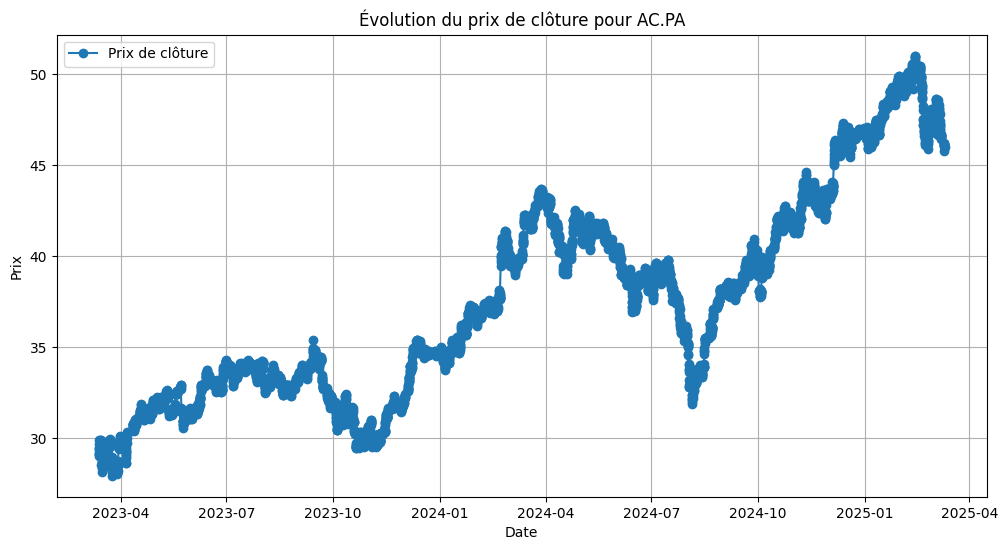

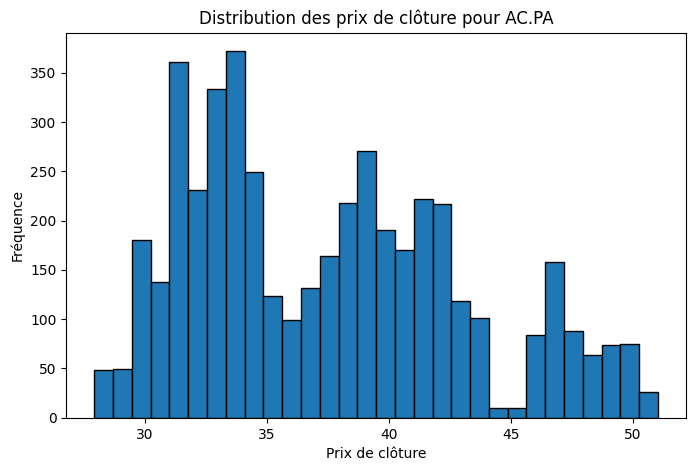

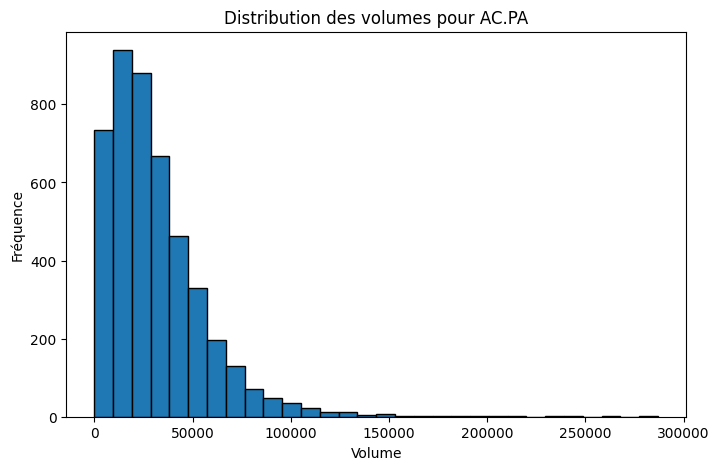

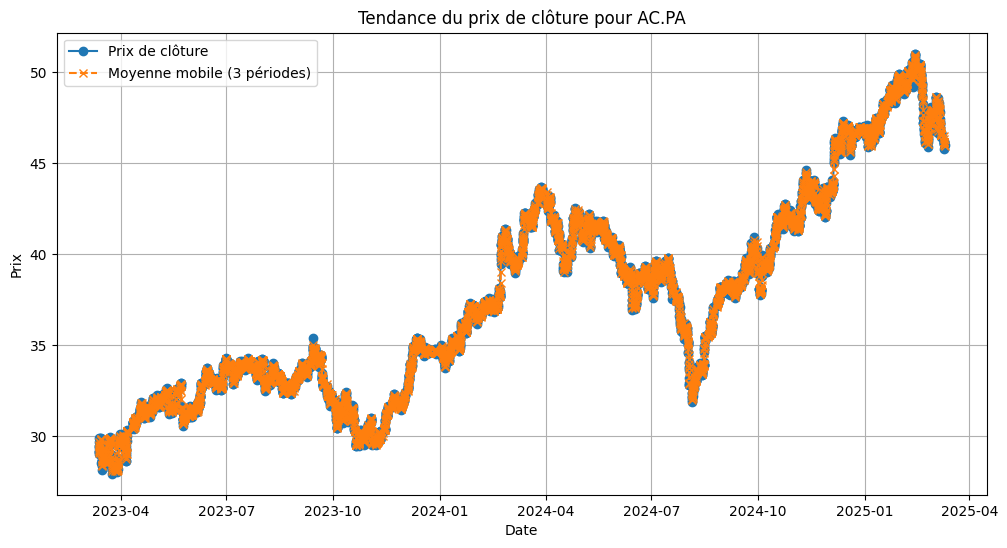


Anomalies détectées dans le prix de clôture pour AC.PA :
Price                   Datetime      Close
170508 2025-01-22 08:00:00+00:00  48.740002
170548 2025-01-22 09:00:00+00:00  48.830002
170588 2025-01-22 10:00:00+00:00  48.810001
170628 2025-01-22 11:00:00+00:00  49.029999
170668 2025-01-22 12:00:00+00:00  49.060001
...                          ...        ...
177868 2025-02-19 12:00:00+00:00  49.169998
177908 2025-02-19 13:00:00+00:00  49.000000
177988 2025-02-19 15:00:00+00:00  48.720001
178028 2025-02-19 16:00:00+00:00  48.730000
180868 2025-03-03 15:00:00+00:00  48.660000

[179 rows x 2 columns]


In [23]:
# ---------------------------
# C. Analyse Exploratoire des Données (EDA)
# ---------------------------

# Pour illustrer l'analyse, nous prendrons un ticker en exemple (ici "AC.PA")
ticker = "AC.PA"
# Filtrer le DataFrame pivoté pour ne garder que les données correspondant au ticker choisi
df_ticker = df_pivot[df_pivot['Ticker'] == ticker].copy()

# C.1 Visualisation de la série temporelle du prix de clôture
plt.figure(figsize=(12, 6))
plt.plot(df_ticker['Datetime'], df_ticker['Close'], marker='o', linestyle='-', label="Prix de clôture")
plt.title(f"Évolution du prix de clôture pour {ticker}")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.show()

# C.2 Analyse de la distribution des prix de clôture

# Histogramme de la distribution des prix de clôture
plt.figure(figsize=(8, 5))
plt.hist(df_ticker['Close'].dropna(), bins=30, edgecolor='black')
plt.title(f"Distribution des prix de clôture pour {ticker}")
plt.xlabel("Prix de clôture")
plt.ylabel("Fréquence")
plt.show()

# C.3 Analyse de la distribution des volumes (si la colonne 'Volume' est présente)
if 'Volume' in df_ticker.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_ticker['Volume'].dropna(), bins=30, edgecolor='black')
    plt.title(f"Distribution des volumes pour {ticker}")
    plt.xlabel("Volume")
    plt.ylabel("Fréquence")
    plt.show()
else:
    print("\nLa colonne 'Volume' n'est pas disponible pour ce ticker.")

# C.4 Identification des tendances saisonnières et détection d'anomalies

# Calcul d'une moyenne mobile sur 3 périodes pour lisser la série et visualiser la tendance
# La taille de la fenêtre (ici 3) pourra être ajustée en fonction de vos données
df_ticker['Rolling_Mean'] = df_ticker['Close'].rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_ticker['Datetime'], df_ticker['Close'], marker='o', linestyle='-', label="Prix de clôture")
plt.plot(df_ticker['Datetime'], df_ticker['Rolling_Mean'], marker='x', linestyle='--', label="Moyenne mobile (3 périodes)")
plt.title(f"Tendance du prix de clôture pour {ticker}")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.show()

# Détection d'anomalies :
# On identifie les points dont le prix de clôture s'écarte de plus de 2 écarts-types de la moyenne
mean_close = df_ticker['Close'].mean()
std_close = df_ticker['Close'].std()
anomalies = df_ticker[(df_ticker['Close'] < mean_close - 2 * std_close) | (df_ticker['Close'] > mean_close + 2 * std_close)]
print(f"\nAnomalies détectées dans le prix de clôture pour {ticker} :")
print(anomalies[['Datetime', 'Close']])

# 2. Feature Engineering

In [24]:
# On part de notre DataFrame pivoté "df_pivot" issu de la préparation des données.
# Nous créons une copie pour ajouter nos nouvelles variables.
df_features = df_pivot.copy()

In [25]:
# =======================================================
# A. Extraction d'informations temporelles
# =======================================================
# À partir de la colonne 'Datetime', on extrait l'année, le mois, le jour,
# le jour de la semaine et l'heure.
df_features['Year']      = df_features['Datetime'].dt.year          # Année
df_features['Month']     = df_features['Datetime'].dt.month         # Mois
df_features['Day']       = df_features['Datetime'].dt.day           # Jour du mois
df_features['DayOfWeek'] = df_features['Datetime'].dt.dayofweek     # Jour de la semaine (0=Monday, 6=Sunday)
df_features['Hour']      = df_features['Datetime'].dt.hour          # Heure

In [26]:
# =======================================================
# B. Calcul d'indicateurs techniques pour enrichir les signaux
# =======================================================
# Pour l'exemple, nous allons calculer ces indicateurs pour un ticker spécifique (par exemple "AC.PA").
ticker = "AC.PA"
df_ticker_features = df_features[df_features['Ticker'] == ticker].copy()

# On s'assure que les données sont triées par date pour un calcul correct des indicateurs
df_ticker_features.sort_values('Datetime', inplace=True)

# ----
# Moyennes Mobiles (Moving Averages)
# ----
# Calcul de la moyenne mobile sur 5 périodes et sur 10 périodes à partir du prix de clôture.
df_ticker_features['MA_5']  = df_ticker_features['Close'].rolling(window=5).mean()
df_ticker_features['MA_10'] = df_ticker_features['Close'].rolling(window=10).mean()

# ----
# RSI (Relative Strength Index)
# ----
# Définition d'une fonction pour calculer le RSI avec une période par défaut de 14
def compute_rsi(series, period=14, epsilon=1e-6):
    """
    Calcule le RSI (Relative Strength Index) pour une série de prix,
    en évitant la division par zéro.
    
    Args:
        series (pd.Series): Série temporelle de prix (ex: prix de clôture).
        period (int): Nombre de périodes pour le calcul.
        epsilon (float): Petite valeur pour éviter la division par zéro.
    
    Returns:
        pd.Series: RSI calculé.
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean().replace(0, epsilon)
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Calcul du RSI sur 14 périodes
df_ticker_features['RSI_14'] = compute_rsi(df_ticker_features['Close'], period=14)

# ----
# MACD (Moving Average Convergence Divergence)
# ----
# Calcul des moyennes mobiles exponentielles (EMA) sur 12 et 26 périodes
ema12 = df_ticker_features['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_ticker_features['Close'].ewm(span=26, adjust=False).mean()

# Calcul du MACD en soustrayant l'EMA26 de l'EMA12
df_ticker_features['MACD'] = ema12 - ema26

# Calcul de la ligne de signal, qui est l'EMA du MACD sur 9 périodes
df_ticker_features['MACD_Signal'] = df_ticker_features['MACD'].ewm(span=9, adjust=False).mean()

# Calcul de l'histogramme MACD (différence entre le MACD et sa ligne de signal)
df_ticker_features['MACD_Hist'] = df_ticker_features['MACD'] - df_ticker_features['MACD_Signal']

In [27]:
# =======================================================
# C. Normalisation / Standardisation
# =======================================================
# Pour que les différentes features soient sur une même échelle,
# nous appliquons une normalisation Min-Max sur les indicateurs techniques et le prix de clôture.
from sklearn.preprocessing import MinMaxScaler

# Sélection des colonnes à normaliser
cols_to_normalize = ['Close', 'MA_5', 'MA_10', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist']

# Instanciation du MinMaxScaler
scaler = MinMaxScaler()

# Application de la normalisation et création de nouvelles colonnes avec le suffixe '_norm'
normalized_values = scaler.fit_transform(df_ticker_features[cols_to_normalize])
normalized_columns = [col + '_norm' for col in cols_to_normalize]
df_ticker_features[normalized_columns] = normalized_values

# Supprimer les lignes contenant des NaN (générées par les calculs de moyennes mobiles, RSI, etc.)
df_ticker_features.dropna(inplace=True)

# Affichage des premières lignes du DataFrame enrichi avec les nouvelles features
print("\nFeatures techniques et normalisées pour le ticker", ticker, ":")
print(df_ticker_features.head())


Features techniques et normalisées pour le ticker AC.PA :
Price                  Datetime Ticker      Close       High        Low  \
532   2023-03-14 13:00:00+00:00  AC.PA  29.910000  30.020000  29.549999   
570   2023-03-14 14:00:00+00:00  AC.PA  29.799999  29.930000  29.780001   
608   2023-03-14 15:00:00+00:00  AC.PA  29.840000  29.889999  29.780001   
646   2023-03-14 16:00:00+00:00  AC.PA  29.879999  30.000000  29.850000   
684   2023-03-15 08:00:00+00:00  AC.PA  29.600000  29.820000  29.600000   

Price       Open    Volume  Year  Month  Day  ...      MACD  MACD_Signal  \
532    29.590000  111589.0  2023      3   14  ... -0.097605    -0.151229   
570    29.900000   80909.0  2023      3   14  ... -0.062394    -0.133462   
608    29.809999   41072.0  2023      3   14  ... -0.030905    -0.112951   
646    29.850000   57998.0  2023      3   14  ... -0.002691    -0.090899   
684    29.740000       0.0  2023      3   15  ... -0.002891    -0.073297   

Price  MACD_Hist  Close_norm  MA_

# 3. Structuration des Données pour le Modèle

In [28]:
# A. Segmentation en Séquences
# ---------------------------
def create_sequences(data, window_size, forecast_horizon):
    """
    Crée des séquences d'entrée (X) et des cibles (y) à partir d'une série temporelle.
    
    Args:
        data (np.array): Tableau numpy de forme (nombre_de_points, nombre_de_features).
        window_size (int): Nombre de points temporels à utiliser pour chaque séquence d'entrée.
        forecast_horizon (int): Décalage pour la prédiction (typiquement 1 pour prédire le point immédiatement suivant).
    
    Returns:
        X (np.array): Séquences d'entrée de forme (nombre_de_sequences, window_size, nombre_de_features).
        y (np.array): Valeurs cibles associées, ici nous choisissons le prix de clôture normalisé, de forme (nombre_de_sequences,).
    """
    X, y = [], []
    # Boucle sur la série pour extraire les fenêtres temporelles
    for i in range(len(data) - window_size - forecast_horizon + 1):
        # Extraction de la séquence d'entrée
        X.append(data[i : i + window_size])
        # La cible correspond à la valeur à prédire (ici, le 'Close_norm') au temps i + window_size + forecast_horizon - 1
        y.append(data[i + window_size + forecast_horizon - 1, 0])  # On prend la première colonne (Close_norm) comme cible
    return np.array(X), np.array(y)

# Paramètres pour la segmentation
window_size = 10       # Nombre d'observations dans chaque fenêtre (séquence d'entrée)
forecast_horizon = 1   # Prédire la valeur du prochain pas de temps

# Sélection des colonnes de features normalisées (assurez-vous que ces colonnes ont été créées dans la partie précédente)
feature_columns = ['Close_norm', 'MA_5_norm', 'MA_10_norm', 'RSI_14_norm', 'MACD_norm', 'MACD_Signal_norm', 'MACD_Hist_norm']

# Extraction des données sous forme de tableau numpy à partir du DataFrame enrichi pour le ticker
data_array = df_ticker_features[feature_columns].values

# Création des séquences
X, y = create_sequences(data_array, window_size, forecast_horizon)

# Nettoyer les séquences : retirer celles qui contiennent des valeurs NaN
mask = ~np.isnan(X).any(axis=(1,2))
X = X[mask]
y = y[mask]

print("Forme des séquences d'entrée X après nettoyage :", X.shape)
print("Forme des cibles y après nettoyage :", y.shape)


Forme des séquences d'entrée X après nettoyage : (4551, 10, 7)
Forme des cibles y après nettoyage : (4551,)


In [29]:
# ---------------------------
# B. Séparation des Ensembles
# ---------------------------

# On va séparer nos séquences en 70% pour l'entraînement, 15% pour la validation et 15% pour le test.

# Calcul du nombre total de séquences générées
total_sequences = X.shape[0]

# Indices de découpe basés sur une répartition chronologique
train_end = int(0.7 * total_sequences)
val_end   = int(0.85 * total_sequences)

# Création des ensembles d'entraînement, validation et test
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

print("Taille de l'ensemble d'entraînement :", X_train.shape, y_train.shape)
print("Taille de l'ensemble de validation :", X_val.shape, y_val.shape)
print("Taille de l'ensemble de test :", X_test.shape, y_test.shape)

Taille de l'ensemble d'entraînement : (3185, 10, 7) (3185,)
Taille de l'ensemble de validation : (683, 10, 7) (683,)
Taille de l'ensemble de test : (683, 10, 7) (683,)


# 4. Conception et Construction du Modèle Transformer

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [31]:
# A. Définition d'une couche de Positional Encoding
# Cette couche permet d'ajouter une information de position aux embeddings afin de conserver l'ordre temporel.
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, model_dim):
        """
        Args:
            max_len (int): Longueur maximale des séquences.
            model_dim (int): Dimension de l'espace d'embedding.
        """
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(max_len, model_dim)

    def positional_encoding(self, max_len, model_dim):
        # Calcul des positions et des dimensions
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(model_dim)[np.newaxis, :]
        # Calcul des taux d'angle suivant la formule du Transformer
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(model_dim))
        angle_rads = pos * angle_rates

        # Application de sin aux indices pairs et de cos aux indices impairs
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        # Ajout d'une dimension batch
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        # inputs: (batch_size, sequence_length, model_dim)
        seq_len = tf.shape(inputs)[1]
        # Ajout du positional encoding à chaque vecteur d'embedding
        return inputs + self.pos_encoding[:, :seq_len, :]

In [32]:
# B. Définition d'un bloc Transformer
def transformer_block(inputs, model_dim, num_heads, ff_dim, dropout_rate=0.1):
    """
    Applique un bloc Transformer comprenant :
    - Une couche d'attention multi-tête.
    - Une connexion résiduelle suivie d'une normalisation de couche.
    - Un réseau feed-forward suivi d'une normalisation.
    
    Args:
        inputs (Tensor): Entrée du bloc, de forme (batch_size, sequence_length, model_dim).
        model_dim (int): Dimension de l'espace d'embedding.
        num_heads (int): Nombre de têtes dans l'attention multi-tête.
        ff_dim (int): Dimension interne du réseau feed-forward.
        dropout_rate (float): Taux de dropout pour régularisation.
        
    Returns:
        Tensor: Sortie du bloc Transformer.
    """
    # Couche d'attention multi-tête appliquée sur la même séquence pour self-attention
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=model_dim)(inputs, inputs)
    # Ajout du dropout et connexion résiduelle suivie d'une normalisation
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attn_output)
    
    # Réseau feed-forward en deux couches
    ffn = layers.Dense(ff_dim, activation='relu')(out1)
    ffn = layers.Dense(model_dim)(ffn)
    ffn_output = layers.Dropout(dropout_rate)(ffn)
    # Ajout d'une seconde connexion résiduelle suivie d'une normalisation
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

In [33]:
# -----------------------------------------------------------
# C. Paramètres et Construction du Modèle Transformer
# -----------------------------------------------------------

# Paramètres du modèle
sequence_length = window_size             # Utilisation de la fenêtre définie précédemment
num_features = len(feature_columns)        # Nombre de features normalisées utilisées
model_dim = 64                             # Dimension des embeddings (à ajuster selon vos besoins)
num_heads = 4                              # Nombre de têtes dans la couche d'attention
ff_dim = 128                               # Dimension du réseau feed-forward
num_transformer_blocks = 2                 # Nombre de blocs Transformer empilés

# Définition de l'entrée du modèle : séquences de forme (sequence_length, num_features)
inputs = layers.Input(shape=(sequence_length, num_features))

# Embedding : Projection de chaque vecteur d'entrée dans un espace de dimension model_dim
x = layers.Dense(model_dim)(inputs)

# Ajout du Positional Encoding pour intégrer l'information de position
x = PositionalEncoding(max_len=sequence_length, model_dim=model_dim)(x)

# Empilement de plusieurs blocs Transformer
for _ in range(num_transformer_blocks):
    x = transformer_block(x, model_dim, num_heads, ff_dim)

# Global Average Pooling pour résumer l'information temporelle en un vecteur unique
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)

# Couche de sortie pour la régression (prédiction d'une seule valeur, ici le prix normalisé)
outputs = layers.Dense(1)(x)

# Construction du modèle
model = models.Model(inputs=inputs, outputs=outputs)

# 4.4 Compilation du Modèle
# Utilisation de l'erreur quadratique moyenne (MSE) comme fonction de perte et de l'optimiseur Adam.
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Affichage du résumé du modèle pour vérifier l'architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10, 64)    │        512 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 10, 64)    │          0 │ dense_6[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     66,368 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 64)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10, 64)    │      8,256 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 10, 64)    │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 10, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 10, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 10, 64)    │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Entraînement du Modèle

In [34]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [35]:
# Callback pour sauvegarder le modèle avec la meilleure performance sur l'ensemble de validation.
# Le modèle sera sauvegardé dans le fichier 'best_transformer_model.h5'.
checkpoint_callback = ModelCheckpoint(
    'best_transformer_model.h5',      # Nom du fichier de sauvegarde
    monitor='val_loss',               # Surveille la perte sur l'ensemble de validation
    save_best_only=True,              # Sauvegarde uniquement si la performance s'améliore
    verbose=1
)

# Callback pour arrêter l'entraînement si la perte de validation n'évolue pas pendant un certain nombre d'époques.
early_stopping_callback = EarlyStopping(
    monitor='val_loss',               # Surveille la perte de validation
    patience=10,                      # Nombre d'époques sans amélioration avant d'arrêter l'entraînement
    verbose=1,
    restore_best_weights=True         # Restaure les poids du meilleur modèle rencontré
)

# Callback pour réduire le taux d'apprentissage en cas de stagnation de la perte de validation.
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',               # Surveille la perte de validation
    factor=0.5,                       # Réduction du taux d'apprentissage par un facteur de 0.5
    patience=5,                       # Nombre d'époques sans amélioration avant de réduire le taux d'apprentissage
    verbose=1
)

# Liste des callbacks à utiliser durant l'entraînement
callbacks = [checkpoint_callback, early_stopping_callback, reduce_lr_callback]

# Entraînement du modèle sur l'ensemble d'entraînement avec validation sur l'ensemble de validation.
# Ici, on définit 50 époques et une taille de lot (batch_size) de 32. Ces paramètres peuvent être ajustés.
history = model.fit(
    X_train, y_train,
    epochs=50,                        # Nombre d'époques d'entraînement
    batch_size=32,                    # Taille de lot
    validation_data=(X_val, y_val),   # Données de validation
    callbacks=callbacks               # Liste des callbacks
)

Epoch 1/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8922 - mae: 0.6582
Epoch 1: val_loss improved from inf to 0.03095, saving model to best_transformer_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.8760 - mae: 0.6503 - val_loss: 0.0310 - val_mae: 0.1648 - learning_rate: 0.0010
Epoch 2/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0521 - mae: 0.1792
Epoch 2: val_loss improved from 0.03095 to 0.00427, saving model to best_transformer_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0518 - mae: 0.1785 - val_loss: 0.0043 - val_mae: 0.0620 - learning_rate: 0.0010
Epoch 3/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0241 - mae: 0.1234
Epoch 3: val_loss improved from 0.00427 to 0.00058, saving model to best_transformer_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0240 - mae: 0.1230 - val_loss: 5.7912e-04 - val_mae: 0.0199 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0101 - mae: 0.0799
Epoch 4: val_loss improved from 0.00058 to 0.00024, saving model to best_transformer_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0101 - mae: 0.0798 - val_loss: 2.4402e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0055 - mae: 0.0587
Epoch 5: val_loss did not improve from 0.00024
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0055 - mae: 0.0587 - val_loss: 3.5001e-04 - val_mae: 0.0158 - learning_rate: 0.0010
Epoch 6/50
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0035 - mae: 0.0471
Epoch 6: val_loss did not improve from 0.00024
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0035 - mae: 0.0470 - val_loss: 5.1277e-04 - val_mae: 0.0198 - learning_rate: 0.0010
Epoch 7/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - mae: 0.0384
Epoch 7: val_loss improved from 0.00024 to 0.00020, saving model to best_transformer_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0024 - mae: 0.0384 - val_loss: 1.9521e-04 - val_mae: 0.0111 - learning_rate: 0.0010
Epoch 8/50
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - mae: 0.0344
Epoch 8: val_loss did not improve from 0.00020
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0019 - mae: 0.0344 - val_loss: 4.9228e-04 - val_mae: 0.0194 - learning_rate: 0.0010
Epoch 9/50
 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - mae: 0.0314
Epoch 9: val_loss did not improve from 0.00020

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0015 - mae: 0.0313 - val_loss: 3.9394e-04 - val_mae: 0.0172 - learning_rate: 0.0010
Epoch 10/50
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - mae: 0.0295
Epoch 10: val_loss did not improve from 0.00020
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0014 - mae: 0.0295 - val_loss: 6.2539e-04 - val_mae: 0.0225 - learning_rat

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.8152e-04 - mae: 0.0245 - val_loss: 1.7140e-04 - val_mae: 0.0105 - learning_rate: 2.5000e-04
Epoch 17/50
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0010 - mae: 0.0248
Epoch 17: val_loss did not improve from 0.00017
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0010 - mae: 0.0248 - val_loss: 5.9772e-04 - val_mae: 0.0219 - learning_rate: 2.5000e-04
Epoch 18/50
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9.4393e-04 - mae: 0.0239
Epoch 18: val_loss did not improve from 0.00017
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.4484e-04 - mae: 0.0239 - val_loss: 0.0012 - val_mae: 0.0324 - learning_rate: 2.5000e-04
Epoch 19/50
 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0010 - mae: 0.0254
Epoch 19: val_loss did not improve from 0.00017

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0010 - mae: 0.0254 - val_loss: 5.7544e-04 - val_m

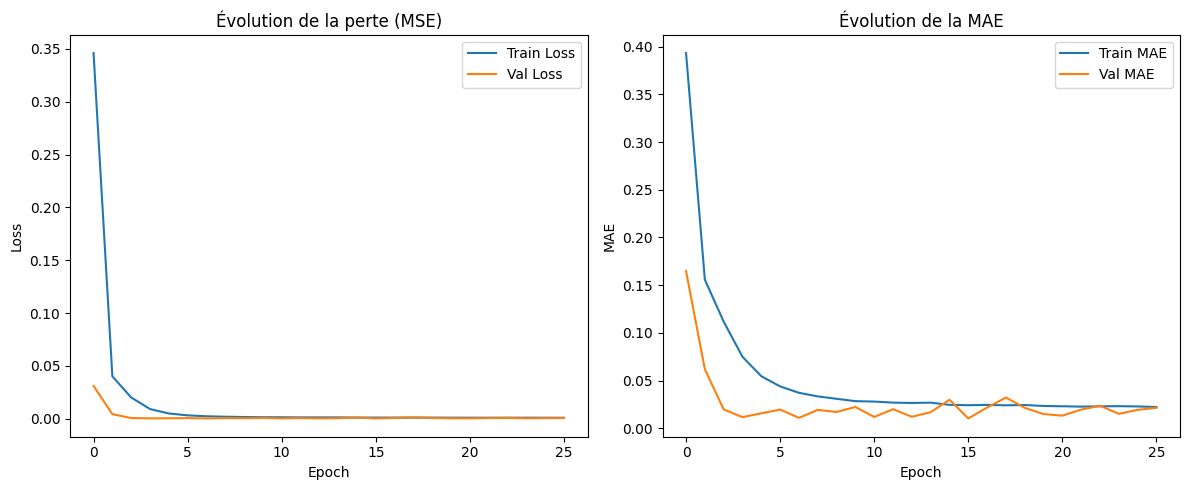

In [37]:
# ---------------------------
# Visualisation de l'évolution de l'entraînement
# ---------------------------

# Import de matplotlib pour tracer l'évolution de la loss et de la MAE au cours des époques
import matplotlib.pyplot as plt

# Tracé des courbes d'évolution de la loss (MSE) et de la MAE pour l'entraînement et la validation.
plt.figure(figsize=(12, 5))

# Sous-graphique pour la loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Évolution de la perte (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Sous-graphique pour la MAE (Mean Absolute Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Évolution de la MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 6. Évaluation et Visualisation des Performances du Modèle

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

In [39]:
# A. Évaluation Quantitative sur l'ensemble de test
# -----------------------------------------
# Évaluer le modèle sur l'ensemble de test avec les métriques définies lors de la compilation.
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print("\nÉvaluation sur l'ensemble de test :")
print("Test Loss (MSE) :", test_loss)
print("Test MAE :", test_mae)

# Prédire les valeurs sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer des métriques supplémentaires : RMSE, MAE et R²
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMétriques supplémentaires sur l'ensemble de test :")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")
print(f"R² : {r2}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.4216e-04 - mae: 0.0187

Évaluation sur l'ensemble de test :
Test Loss (MSE) : 0.000842373410705477
Test MAE : 0.023996789008378983
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Métriques supplémentaires sur l'ensemble de test :
RMSE : 0.029023670395183745
MAE : 0.09675881742960021
R² : 0.9030495244750167


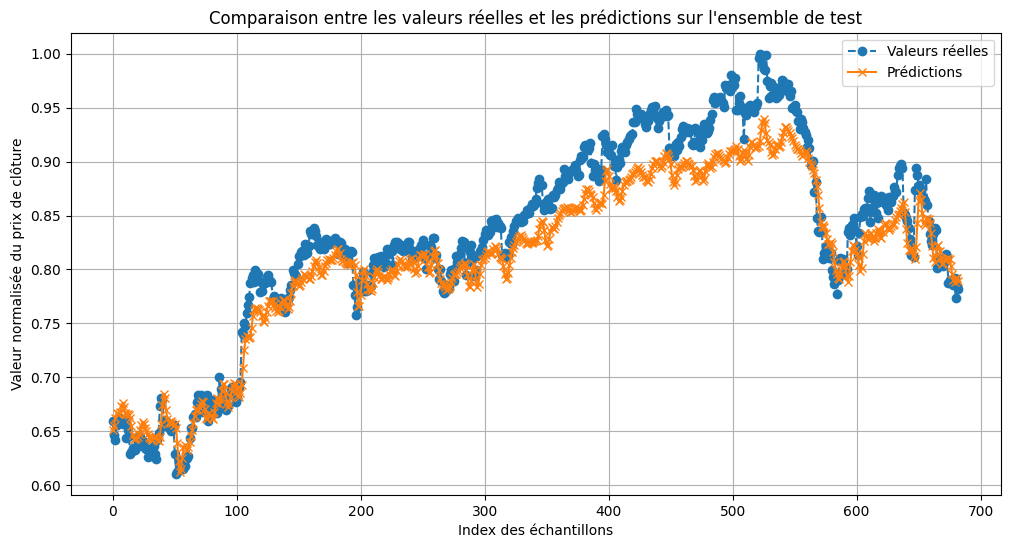

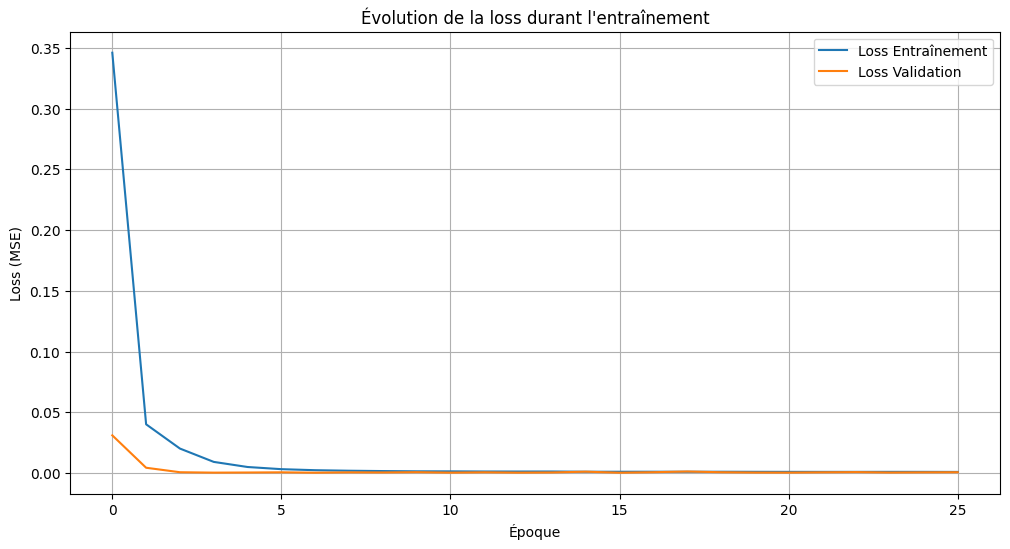

In [40]:
# B. Visualisation des Résultats
# -----------------------------------------
# B.1. Comparaison entre les valeurs réelles et les prédictions
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Valeurs réelles', marker='o', linestyle='--')
plt.plot(y_pred, label='Prédictions', marker='x', linestyle='-')
plt.title("Comparaison entre les valeurs réelles et les prédictions sur l'ensemble de test")
plt.xlabel("Index des échantillons")
plt.ylabel("Valeur normalisée du prix de clôture")
plt.legend()
plt.grid(True)
plt.show()

# B.2. Visualisation de l'évolution de la loss durant l'entraînement
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Loss Entraînement')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title("Évolution de la loss durant l'entraînement")
plt.xlabel("Époque")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# 7. Simulation de Portefeuille (Backtesting)

In [42]:
# --- Préparation des données pour le backtesting ---

# Pour la simulation, nous avons besoin à la fois des valeurs prédites et réelles en échelle brute.
# Nous avons travaillé avec des valeurs normalisées. Pour revenir aux valeurs brutes, nous utilisons les min et max du prix.
close_min = df_ticker_features['Close'].min()
close_max = df_ticker_features['Close'].max()

# Convertir les prédictions (y_pred) en prix bruts :
y_pred_raw = y_pred * (close_max - close_min) + close_min

# Convertir les cibles de test (y_test, qui sont normalisées) en prix bruts.
y_test_raw = y_test * (close_max - close_min) + close_min

# Remarque : nous supposons ici que la variable 'raw_y' (les prix bruts issus du DataFrame) est alignée avec y_test.
# Si vous avez créé vos séquences via une fonction renvoyant (X, y, raw_y), procédez alors à la séparation du jeu de test :
total_sequences = X.shape[0]
train_end = int(0.7 * total_sequences)
val_end   = int(0.85 * total_sequences)
# raw_y_test correspond aux valeurs brutes pour le jeu de test
#raw_y_test = raw_y[val_end:]

In [43]:
# --- Définition de la stratégie de trading ---

threshold = 0.01  # Seuil de 1% pour déclencher une opération

# Conditions initiales
initial_capital = 10000.0
capital = initial_capital
position = 0       # Nombre d'actions détenues (0 si pas investi)
portfolio_values = []  # Liste pour stocker la valeur du portefeuille à chaque étape
positions = []         # Pour suivre si nous sommes investis (True/False)
trades = []            # Pour enregistrer les signaux d'achat et de vente (action, indice, prix)

# Simulation sur chaque période du jeu de test
# Nous parcourons le tableau y_test_raw (les prix réels convertis) et utilisons y_pred_raw (les prédictions converties)
for i in range(len(y_test_raw)):
    current_price = y_test_raw[i]      # Prix réel à l'instant i
    predicted_price = y_pred_raw[i]      # Prix prédit à l'instant i

    # --- Signal d'achat : Si nous ne sommes pas investis et que la prédiction anticipe une hausse significative ---
    if position == 0 and predicted_price > current_price * (1 + threshold):
        # Investir tout le capital pour acheter des actions
        position = capital / current_price  # Nombre d'actions achetées
        capital = 0                         # Tout le capital est investi
        trades.append(('buy', i, current_price))
    
    # --- Signal de vente : Si nous sommes investis et que la prédiction anticipe une baisse significative ---
    elif position > 0 and predicted_price < current_price * (1 - threshold):
        # Vendre toutes les actions détenues
        capital = position * current_price
        position = 0
        trades.append(('sell', i, current_price))
    
    # Calcul de la valeur du portefeuille : capital liquide + valeur des actions détenues
    portfolio_value = capital + position * current_price
    portfolio_values.append(portfolio_value)
    positions.append(position > 0)

In [44]:
# --- Calcul des performances du portefeuille ---

portfolio_values = np.array(portfolio_values)
total_return = (portfolio_values[-1] - initial_capital) / initial_capital

# Calcul des rendements périodiques (returns)
returns = np.diff(portfolio_values) / portfolio_values[:-1]
volatility = np.std(returns)
sharpe_ratio = np.mean(returns) / (volatility + 1e-6)  # Ajout d'une petite valeur pour éviter la division par zéro

# Calcul du maximum drawdown (retrait maximal)
peak = portfolio_values[0]
max_drawdown = 0
for value in portfolio_values:
    if value > peak:
        peak = value
    drawdown = (peak - value) / peak
    if drawdown > max_drawdown:
        max_drawdown = drawdown

print("\nPerformances du portefeuille simulé :")
print(f"Rendement total : {total_return * 100:.2f}%")
print(f"Volatilité : {volatility * 100:.2f}%")
print(f"Ratio de Sharpe : {sharpe_ratio:.2f}")
print(f"Maximum Drawdown : {max_drawdown * 100:.2f}%")


Performances du portefeuille simulé :
Rendement total : 7.55%
Volatilité : 0.23%
Ratio de Sharpe : 0.05
Maximum Drawdown : 3.45%


In [45]:
# --- Benchmark : stratégie Buy and Hold ---
# Simuler l'achat à l'ouverture du test et la vente à la fin
benchmark_return = (y_test_raw[-1] / y_test_raw[0] - 1) * 100
print(f"\nPerformance du benchmark (Buy and Hold) : {benchmark_return:.2f}%")


Performance du benchmark (Buy and Hold) : 6.53%


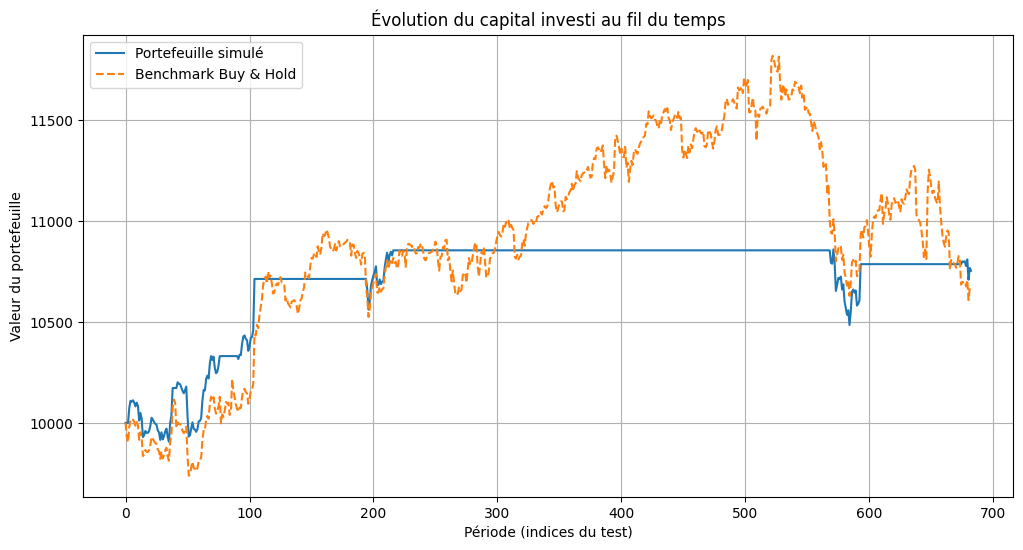

In [46]:
# --- Visualisation de la performance du portefeuille ---

plt.figure(figsize=(12, 6))
plt.plot(portfolio_values, label='Portefeuille simulé')
# On trace une ligne horizontale reliant le capital initial et la valeur finale du benchmark pour comparaison
benchmark_values = initial_capital * (y_test_raw / y_test_raw[0])
plt.plot(benchmark_values, label='Benchmark Buy & Hold', linestyle='--')
plt.title("Évolution du capital investi au fil du temps")
plt.xlabel("Période (indices du test)")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()

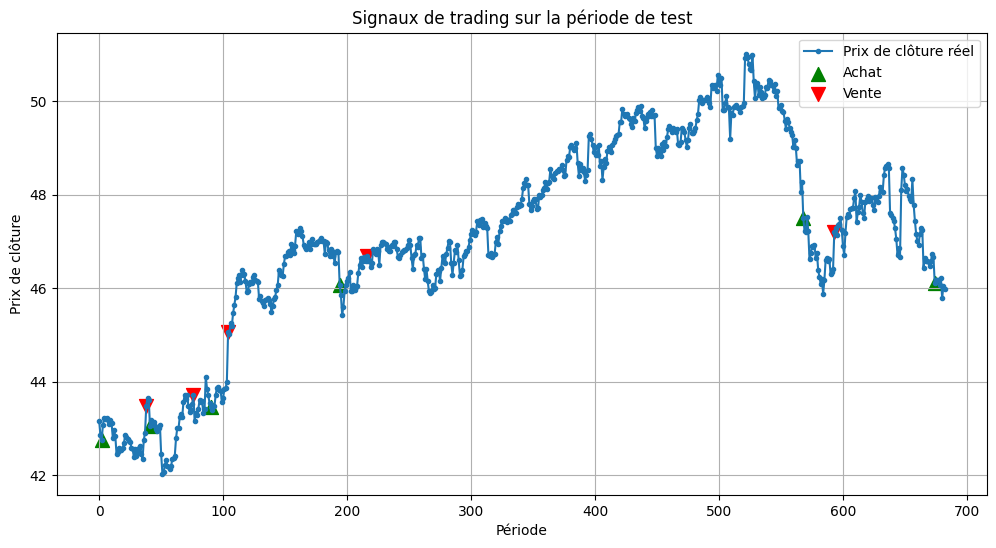

In [52]:
# --- Visualisation des signaux de trading sur le graphique des prix ---
plt.figure(figsize=(12, 6))
plt.plot(y_test_raw, label='Prix de clôture réel', marker='.', linestyle='-')
for trade in trades:
    action, idx, price = trade
    if action == 'buy':
        plt.scatter(idx, price, marker='^', color='green', s=100, label='Achat' if 'Achat' not in plt.gca().get_legend_handles_labels()[1] else "")
    elif action == 'sell':
        plt.scatter(idx, price, marker='v', color='red', s=100, label='Vente' if 'Vente' not in plt.gca().get_legend_handles_labels()[1] else "")
plt.title("Signaux de trading sur la période de test")
plt.xlabel("Période")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.show()